# Imports

In [74]:
import os, sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
project_root
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root already in sys.path


In [75]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import animation

# Getting nodes and edges information

In [76]:
# Get centroids from csv
centroids_arr = np.loadtxt("../08_/npt-HK4_centroids.csv",delimiter=',',skiprows=1,usecols=range(1,4))

# Get unblocked pairs
pairs = np.loadtxt("../../data/processed/unblocked_pairs_2.csv",delimiter=',',dtype=int)

# Get pairs but instead of ID use coordinate
edges_arr = np.empty(shape=(pairs.shape[0],2,3))
numerator = 0
for (p,q) in pairs:
    edges_arr[numerator] = [centroids_arr[p-1],centroids_arr[q-1]]
    numerator += 1
edges_arr

array([[[ 12.93679211,   2.7423158 ,   2.57579365],
        [116.29396834,   4.48973181,  -0.1274213 ]],

       [[ 12.93679211,   2.7423158 ,   2.57579365],
        [  6.27341856,  11.06011143,   0.37769041]],

       [[ 12.93679211,   2.7423158 ,   2.57579365],
        [118.76144217, 113.71813061, 105.15847717]],

       ...,

       [[102.18401191,  23.73036978,  26.92006991],
        [113.64655318,  22.12038289,  24.86587994]],

       [[ 90.4475213 ,   0.53755606,  60.36063033],
        [ 83.65040201,   8.10962038,  66.90861263]],

       [[ 41.38693522,  39.54353397,  39.56389338],
        [ 46.28086574,  47.74529441,  38.82417959]]], shape=(3597, 2, 3))

# Parsing e-coupling data, find duplicates

In [77]:
# Get e-coupling data from file
data = np.loadtxt(
    "C:/Users/user/OneDrive/Documents/intern-stuff/git/kmc-charge-transport-organic-semiconductor/data/e-coupling_with_nn_distance.txt",
    delimiter="\t",
    skiprows=1,
)
mol_i, mol_j_nearest, extracted_value, Distance_nm, NN_Distance_nm = zip(*data)

mol_i = list(map(int,mol_i))
mol_j_nearest = list(map(int,mol_j_nearest))
e_coupled_pairs = list(zip(mol_i, mol_j_nearest))

# Fix order of ID, lower number on the left 
e_coupled_pairs_arr = [(None,)] * len(e_coupled_pairs) #empty list to append into
num = 0
for (p,q) in e_coupled_pairs:
    if p > q:
        e_coupled_pairs_arr[num] = (q,p)
    else:
        e_coupled_pairs_arr[num] = (p,q)
    num +=1

# Finding duplicate pairs
unique_pairs = list(set(e_coupled_pairs_arr))
seen = set()
duplicates = []
for item in e_coupled_pairs_arr:
    if item in seen:
        if item not in duplicates:
            duplicates.append(item)
    else:
        seen.add(item)

print(duplicates)

# e_coupled_pairs_arr = np.unique(e_coupled_pairs_arr,axis=0)

[(1005, 1028), (1034, 1048), (1001, 1080), (1007, 1163), (1129, 1165), (1026, 1178), (1060, 1197), (115, 1199), (1169, 1218), (1040, 1242), (1089, 1262), (126, 1101), (1226, 1285), (104, 1292), (1139, 1300), (1267, 1315), (1102, 1318), (1206, 1330), (117, 1333), (1136, 1336), (1033, 1340), (1289, 1351), (11, 135), (1240, 1362), (1095, 1369), (1024, 1374), (1194, 1377), (1042, 1391), (1293, 1392), (139, 1047), (13, 1074), (1087, 1404), (1186, 1415), (114, 1425), (142, 1120), (1277, 1432), (1248, 1439), (1027, 1440), (1013, 1442), (1196, 1443), (1110, 1449), (144, 1388), (1255, 1462), (1279, 1470), (1046, 1487), (123, 1489), (146, 1491), (1078, 1493), (149, 1317), (15, 1140), (162, 1332), (170, 1409), (186, 1230), (187, 1017), (188, 1081), (191, 1481), (201, 1066), (205, 1419), (207, 1364), (208, 1381), (20, 1288), (217, 1385), (220, 1179), (221, 1099), (229, 1143), (232, 1173), (234, 235), (239, 1061), (185, 240), (241, 1146), (242, 1305), (253, 1032), (178, 260), (269, 1268), (26, 1437

# Set edge attributes

In [78]:
# This block is getting a dictionary with both e-coupling and distance data

from utils import mic_helper

e_coupled_pairs_dict = {}
for item in e_coupled_pairs:
    p, q = item
    index = e_coupled_pairs.index(item)
    
    e_coupling = extracted_value[index]
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=11.24798)
    
    if p < q:
        pair_order = (p,q)
    else:
        pair_order = (q,p)

    if item in e_coupled_pairs_dict: # if duplicate
        if current_value := e_coupled_pairs_dict[item]["e_coupling"] < e_coupling:
            e_coupled_pairs_dict[pair_order] = {"e_coupling": e_coupling, "distance": distance}
    else:
        e_coupled_pairs_dict[pair_order] = {"e_coupling": e_coupling, "distance": distance}

print(e_coupled_pairs_dict)

{(698, 1000): {'e_coupling': np.float64(0.0086763445541123), 'distance': 4.402322481941357}, (1001, 1080): {'e_coupling': np.float64(0.0522194249137626), 'distance': 7.901742059987741}, (758, 1002): {'e_coupling': np.float64(0.0244441753032811), 'distance': 5.656413316087623}, (1003, 1459): {'e_coupling': np.float64(0.0306991520067734), 'distance': 5.154230147593823}, (1005, 1028): {'e_coupling': np.float64(0.009611212783183), 'distance': 7.290699230843103}, (16, 1006): {'e_coupling': np.float64(0.0550998780513319), 'distance': 4.2681283860637755}, (1007, 1163): {'e_coupling': np.float64(0.3328845358823565), 'distance': 4.539177732143585}, (405, 1008): {'e_coupling': np.float64(0.0764020618498078), 'distance': 4.2957962273407535}, (576, 1011): {'e_coupling': np.float64(0.0609941396976673), 'distance': 7.096246070506358}, (180, 1012): {'e_coupling': np.float64(0.0269324181396068), 'distance': 7.350957773849848}, (1013, 1442): {'e_coupling': np.float64(0.0015448969730038), 'distance': 7.

In [79]:
# This block is for both distance and e-coupling data
pairs_distance = {}

for (p,q) in pairs:
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=11.24798)
    pairs_distance[(p,q)] = {"distance": distance}

In [80]:
# Setting edge attributes
G = nx.Graph()
G.add_nodes_from(list(range(1,1502)))
G.add_edges_from(pairs)

nx.set_edge_attributes(G,e_coupled_pairs_dict)

print(G.edges(data=True))

[(1, np.int64(2), {}), (1, np.int64(4), {}), (1, np.int64(18), {}), (1, np.int64(359), {}), (1, np.int64(847), {}), (2, np.int64(3), {}), (2, np.int64(4), {}), (2, np.int64(18), {}), (2, np.int64(127), {}), (2, np.int64(780), {}), (2, np.int64(984), {}), (3, np.int64(147), {}), (3, np.int64(258), {}), (3, np.int64(1014), {}), (4, np.int64(226), {}), (4, np.int64(1206), {}), (4, np.int64(1330), {}), (5, np.int64(443), {}), (5, np.int64(760), {}), (5, np.int64(1355), {}), (6, np.int64(302), {}), (6, np.int64(436), {}), (6, np.int64(606), {}), (6, np.int64(664), {}), (6, np.int64(1358), {}), (7, np.int64(70), {'e_coupling': np.float64(0.0088295280618374), 'distance': 6.418267027998821}), (7, np.int64(711), {}), (8, np.int64(131), {}), (8, np.int64(346), {}), (8, np.int64(700), {}), (8, np.int64(759), {'e_coupling': np.float64(0.0121424921248464), 'distance': 5.9863739009533505}), (8, np.int64(1219), {}), (8, np.int64(1261), {}), (9, np.int64(558), {}), (9, np.int64(591), {}), (9, np.int64

[12, 45, 111, 193, 282, 314, 281, 167, 73, 19, 4]
4.792804796802132


<BarContainer object of 11 artists>

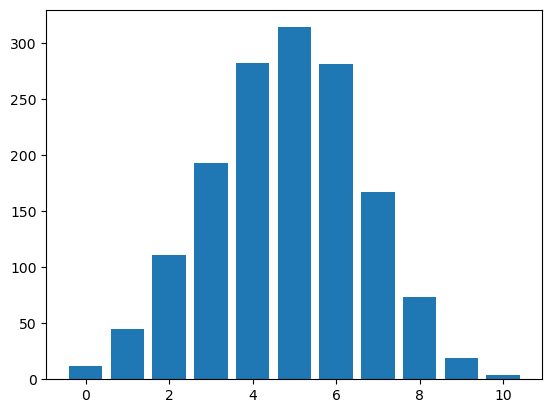

In [81]:
# Check degree and average degree
degree_hist = nx.degree_histogram(G)
print(degree_hist)
x_labels = list(range(len(degree_hist)))

total_nodes = sum(degree_hist)
weighted_total = 0
for item in degree_hist:
    weighted_total += item * degree_hist.index(item)

average = weighted_total/total_nodes

print(average)

plt.bar(x_labels,degree_hist)

In [82]:
# Show edges without e-coupling
edges_without_attributes=[]
for u,v, data in G.edges(data=True):
    if not data:
        edges_without_attributes.append((u,v))

# edges_without_attributes

In [83]:
# add Distance attribute of other edges
nx.set_edge_attributes(G,pairs_distance)

In [84]:
# Complete graph
G.edges(data=True)

EdgeDataView([(1, np.int64(2), {'distance': 3.857197547842398}), (1, np.int64(4), {'distance': 5.868241183841734}), (1, np.int64(18), {'distance': 5.018056555081587}), (1, np.int64(359), {'distance': 3.6013955619274065}), (1, np.int64(847), {'distance': 4.837724290762385}), (2, np.int64(3), {'distance': 3.0562482399857855}), (2, np.int64(4), {'distance': 5.30876584855578}), (2, np.int64(18), {'distance': 5.752876593523602}), (2, np.int64(127), {'distance': 4.553650998530031}), (2, np.int64(780), {'distance': 7.729263791401607}), (2, np.int64(984), {'distance': 5.7014412343867935}), (3, np.int64(147), {'distance': 4.6188731233738345}), (3, np.int64(258), {'distance': 7.588019460172808}), (3, np.int64(1014), {'distance': 7.044566022073431}), (4, np.int64(226), {'distance': 4.867785087003051}), (4, np.int64(1206), {'distance': 3.7773760559843845}), (4, np.int64(1330), {'distance': 6.58394310534083}), (5, np.int64(443), {'distance': 4.942225720939868}), (5, np.int64(760), {'distance': 6.95

# Plotting in matplotlib 3D

In [85]:
nodes = centroids_arr
edges = edges_arr

MovieWriter ffmpeg unavailable; using Pillow instead.


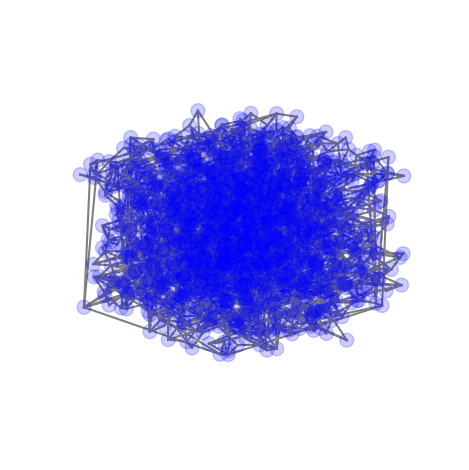

In [86]:
def init():
    ax.clear()
    ax.scatter(*nodes.T, alpha=0.2, s=100, color="blue")
    for vizedge in edges:
        ax.plot(*vizedge.T, color="gray")
    ax.grid(False)
    ax.set_axis_off()


def _frame_update(index):
    ax.view_init(index * 0.2, index * 0.5)


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
fig.tight_layout()

ani = animation.FuncAnimation(
    fig,
    _frame_update,
    init_func=init,
    interval=50,
    cache_frame_data=False,
    frames=100,
)

ani.save(filename="temp.gif")
plt.show()